# Example-03: SVD truncation

In [1]:
# Import

import numpy
import torch

import sys
sys.path.append('..')

from harmonica.util import data_load
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

tensor([4])
tensor([4])
256.656987075       256.656987075       0.0                 
256.119186377       256.119186377       0.0                 
25.642009985        25.642009985        2.13162820728e-14   
25.5735215174       25.5735215174       3.5527136788e-15    
2.6732280530085677e-13
4.652126792043313
4.65212679204333


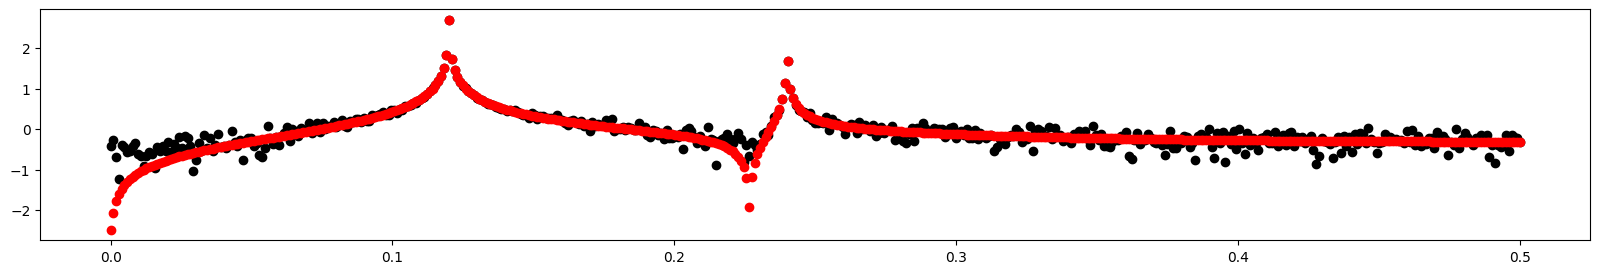

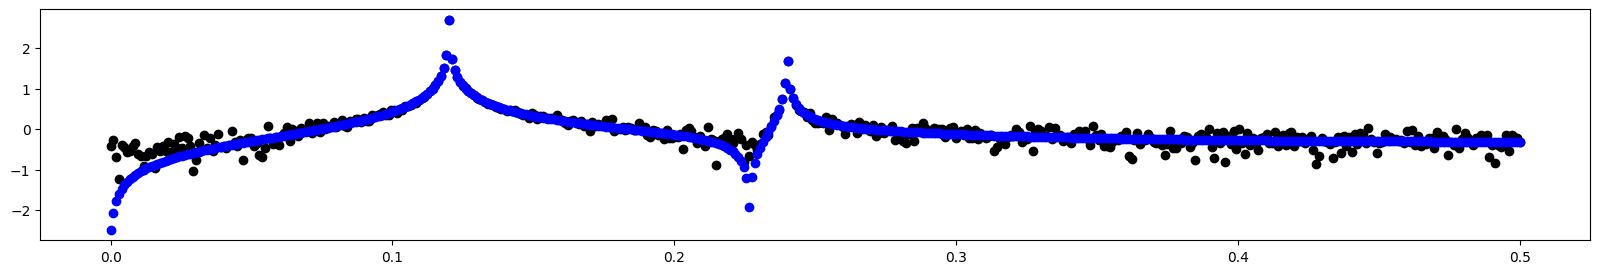

In [3]:
# svd_truncation and svd_truncation_randomized can be used to perform SVD truncation
# svd_truncation performs full SVD and svd_truncation_randomized performs randomized SVD
# In both cases, only the requested number of largest singular values are used to generated truncated matrix
# Truncated matrix is the best rank k approximation of the input
# These functions return list of singular values and truncated matrices

# Generate test signal (real signal with two harmonics and random noise)

length = 1024
time = torch.linspace(1, length, length, dtype=dtype, device=device)
signal = 1.0*torch.sin(2*numpy.pi*0.12*time) + 0.1*torch.sin(2*numpy.pi*0.24*time)
sigma = 1.0E-2
signal.add_(sigma*torch.randn(length, dtype=dtype, device=device))
signal.unsqueeze_(0)

# Generate matrix representation

matrix = Filter.make_matrix(signal)

# Since noise is added, matrix is expected to have full rank

torch.linalg.matrix_rank(matrix)

# Perform SVD truncation (full SVD)

S1, M1 = Filter.svd_truncation(rank=4, matrix=matrix, cpu=True)
print(torch.linalg.matrix_rank(M1))

# Perform SVD truncation (randomized SVD)

S2, M2 = Filter.svd_truncation_randomized(rank=4, matrix=matrix, buffer=8, count=8, cpu=True)
print(torch.linalg.matrix_rank(M2))

# Compare singular values

fmt = 3 * '{:<20.12}'
for s1, s2 in zip(S1.squeeze().cpu(), S2.squeeze().cpu()):
    print(fmt.format(s1, s2, abs(s1 - s2)))
    
# Compare truncated matrices

print(torch.linalg.norm(M1 - M2).cpu().numpy())

# Estimate noise

print(100*abs(sigma-torch.std(matrix - M1).cpu().numpy())/sigma)
print(100*abs(sigma-torch.std(matrix - M2).cpu().numpy())/sigma)

# Convert to signal representation and DFT compare spectra

s1 = Filter.make_signal(M1).squeeze()
s2 = Filter.make_signal(M2).squeeze()
grid = torch.fft.rfftfreq(length, dtype=dtype)

plt.figure(figsize=(20, 3))
plt.scatter(grid, torch.log10(torch.abs(torch.fft.rfft(signal.squeeze()))).cpu(), c='black')
plt.scatter(grid, torch.log10(torch.abs(torch.fft.rfft(s1))).cpu(), c='red')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(grid, torch.log10(torch.abs(torch.fft.rfft(signal.squeeze()))).cpu(), c='black')
plt.scatter(grid, torch.log10(torch.abs(torch.fft.rfft(s2))).cpu(), c='blue')
plt.show()

# Filtering potentialy allows to apply window function with less noise amplification
# Note, signals are assumed to have zero mean
# Remove mean before processing or increase number of requested singular values by one